In [1]:
import matplotlib.pyplot as plt
import re
import os
import json  

In [2]:
def extract_data_from_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    model_pattern = re.compile(
        r'(\w+)_lacency\s*=\s*\[([^\]]+)\].*?'  # 匹配 latency 数据
        r'\1_recall\s*=\s*\[([^\]]+?)\]',  # 匹配 recall 数据
        re.DOTALL
    )

    results = {}
    for match in model_pattern.finditer(content):
        model = match.group(1)
        print("模型名称:", model)
        print("Latency 数据:", match.group(2)) 
        print("Recall 数据:", match.group(3))  

        # 处理 latency 数据
        if match.group(2):
            latency = [
                float(x.strip()) for x in match.group(2).split(',')
                if x.strip()  # 过滤空字符串
            ]
        else:
            latency = []

        # 处理 recall 数据
        if match.group(3):
            recall = [
                float(x.strip()) for x in match.group(3).split(',')
                if x.strip()  
            ]
        else:
            recall = []

        results[model] = {'latency': latency, 'recall': recall}

    return results

In [3]:
files = [
    "script/huatu_recall1_bigann.py",
    "script/huatu_recall1_gist.py",
    "script/huatu_recall1_deep.py",
    "script/huatu_recall1_sift1m.py",
    "script/huatu_recall10_bigann.py",
    "script/huatu_recall10_gist.py",
    "script/huatu_recall10_deep.py",
    "script/huatu_recall10_sift1m.py",
]

output_dir = "output_plots"
os.makedirs(output_dir, exist_ok=True)


data = {}
for file in files:
    print(f"处理文件: {file}")
    extracted_data = extract_data_from_file(file)
    
    recall_type = "recall@10" if "recall10" in file else "recall@1"
    dataset = file.split('_')[-1].split('.')[0].upper()

    if recall_type not in data:
        data[recall_type] = {}
    if dataset not in data[recall_type]:
        data[recall_type][dataset] = {}
    
    data[recall_type][dataset] = extracted_data

json_output_file = os.path.join(output_dir, 'extracted_data.json')
with open(json_output_file, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print(f"所有数据已保存到: {json_output_file}")

处理文件: script/huatu_recall1_bigann.py
模型名称: diskhivf
Latency 数据: 
    4576.65,
    5452.09,
    6297.79,
    8353.75,
    9748.64,
    10905.3,
    11918.1,
    13857.8,
    15679.2,
    19742.2,
    21790.1,


Recall 数据: 
    88.589996,
    91.599998,
    94.269997,
    96.379997,
    97.070000,
    97.349998,
    97.540001,
    98.050003,
    98.519997,
    98.989998,
    99.050003,

模型名称: diskann
Latency 数据: 
    4871.71,
    5458.75,
    6149.85,
    6725.55,
    7495.07,
    7938.95,
    9488.26,
    10605.2,
    12050.32,
    13206.36,
    14479.85,
    17580.26,
    20753.64,

Recall 数据: 
    82.11,
    84.57,
    86.45,
    88,
    89.04,
    90.08,
    91.75,
    92.76,
    93.7,
    94.52,
    95.2,
    96.29,
    96.99,

模型名称: starling
Latency 数据: 
    4793.15,
    5130.33,
    5533.48,
    5902.02,
    6247.53,
    6580.98,
    6976.3,
    7677.99,
    8365.18,
    9041.91,
    9856.84,
    10655.95,
    12221.21,
    13971.92,
    16095.72,
    18101.57,

Recall 数据: 
    83

{'diskhivf': {'latency': [422.471, 749.599, 1053.86, 1351.33, 2042.64, 2832.79, 3733.26, 4861.55, 5871.76], 'recall': [89.849998, 94.790001, 96.449997, 97.480003, 98.709999, 99.239998, 99.550003, 99.760002, 99.82]}, 'diskann': {'latency': [1083.36, 1194.43, 1296.75, 1385.5, 1493.8, 1599.42, 1712.24, 1940.23, 2129.04, 2372.3, 2561.41, 2749.53, 3416.68, 3900.04, 4517.12, 5069.78, 6212.0], 'recall': [82.27, 85.19, 87.52, 88.92, 90.34, 91.5, 92.59, 93.99, 95.03, 95.71, 96.42, 96.82, 97.74, 98.4, 98.82, 99.07, 99.34]}, 'spann': {'latency': [638.0, 688.0, 703.0, 744.0, 884.0, 1002.0, 1164.0, 1586.0, 1978.0, 2955.0, 3927.0, 5861.0], 'recall': [80.64, 81.77, 83.01, 85.5, 88.59, 90.64, 92.06, 94.17, 95.64, 97.37, 98.23, 99.03]}, 'starling': {'latency': [1559.68, 1650.98, 1754.75, 1862.93, 1879.14, 1891.4, 1948.38, 1988.06, 2024.38, 2250.87, 2471.31], 'recall': [82.55, 90.27, 94.22, 95.77, 96.78, 97.41, 97.94, 98.33, 98.58, 99.17, 99.5]}}
diskhivf
diskann
spann
starling
{'diskhivf': {'latency': 

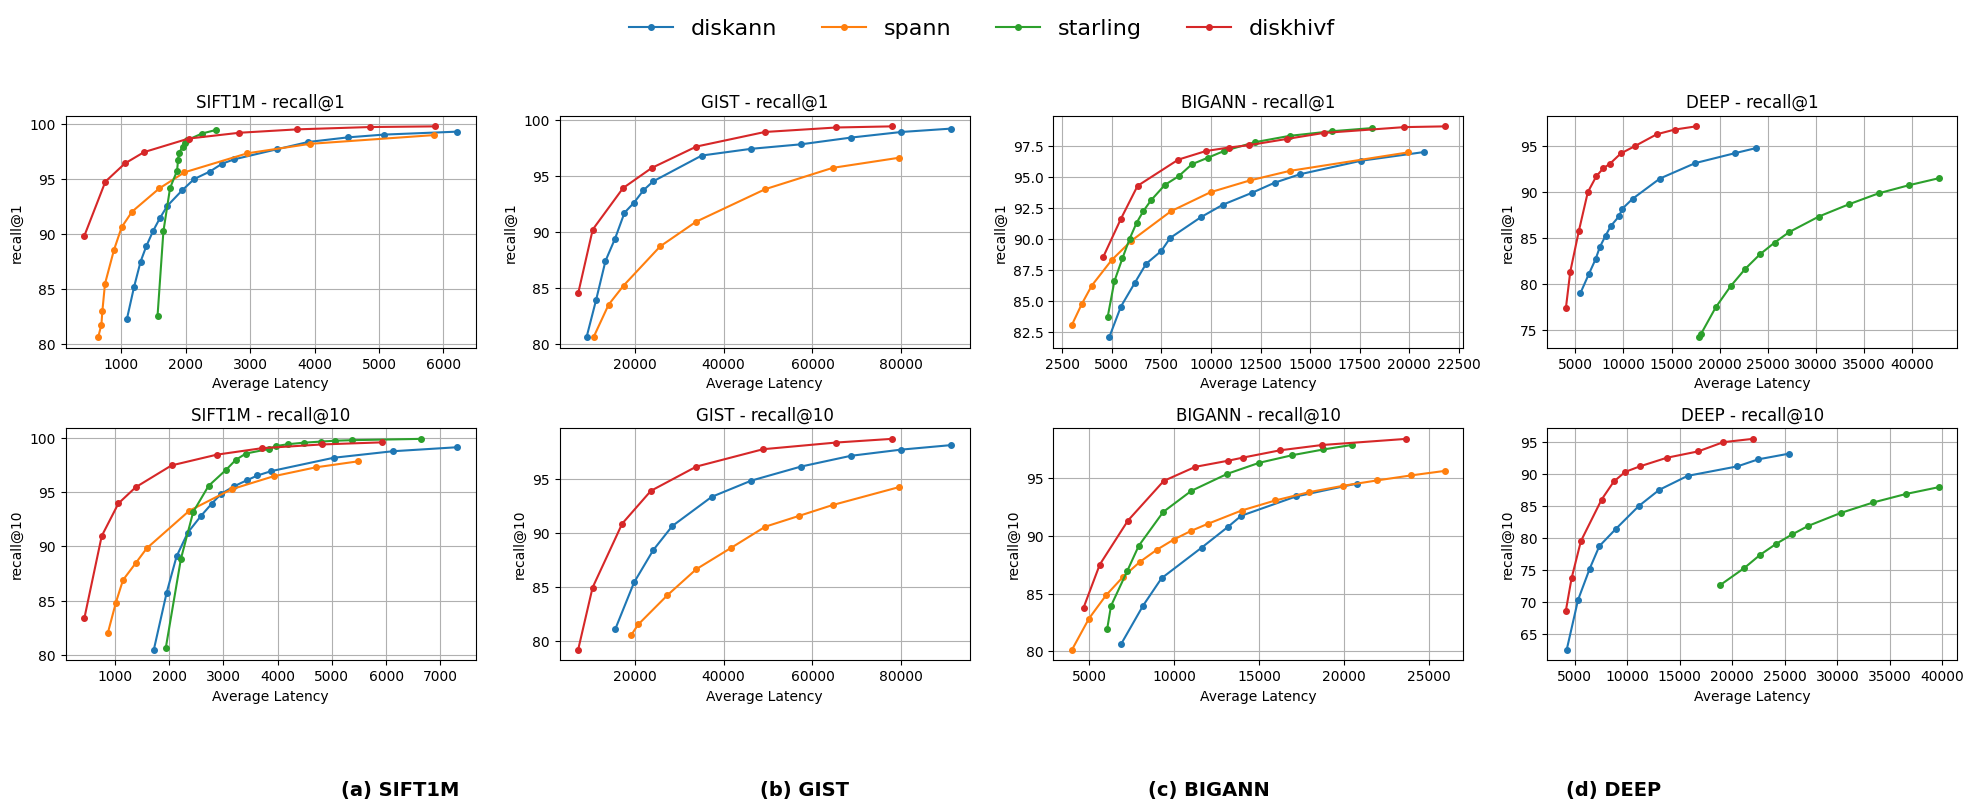

In [4]:
import matplotlib.pyplot as plt

# 假设 `data` 已经从文件中提取并组织好
# 示例数据结构：data[recall_type][dataset][model] = {'latency': ..., 'recall': ...}

fig, axs = plt.subplots(2, 4, figsize=(20, 8))  # 2行4列

models = ['diskann', 'spann', 'starling', 'diskhivf']
datasets = ['SIFT1M', 'GIST', 'BIGANN', 'DEEP']

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, recall_type in enumerate(['recall@1', 'recall@10']):
    for j, dataset in enumerate(datasets):
        ax = axs[i, j]  # 获取对应的子图

        print(data[recall_type][dataset])
        for model in data[recall_type][dataset]:
            print(model)
        for idx, model in enumerate(models):
            print(data[recall_type][dataset])
            if model in data[recall_type][dataset]:
                print(recall_type, dataset, model)
                metrics = data[recall_type][dataset][model]
                color = default_colors[idx]
                ax.plot(metrics['latency'], metrics['recall'], marker='o', markersize=4, label=model, color=color)

        ax.set_title(f'{dataset} - {recall_type}')
        ax.set_xlabel('Average Latency')
        ax.set_ylabel(f'{recall_type}')
        ax.grid(True)
        # ax.legend()

# 将图例和列标签放在下方
fig.legend(models, loc='upper center', ncol=len(models), frameon=False, prop={'size': 16}, bbox_to_anchor=(0.5, 1.0))

# 在图例下面添加列标签
column_labels = ['(a) SIFT1M', '(b) GIST', '(c) BIGANN', '(d) DEEP']
for j in range(len(datasets)):
    ax = axs[0, j]  # 取第一行的子图来获取位置信息
    bbox = ax.get_position()
    # 计算标签的 x 坐标，使其位于子图横坐标标签正下方
    x = bbox.x0 + (bbox.x1 - bbox.x0) / 2
    fig.text(x, 0.01, column_labels[j], ha='center', va='center', fontsize=14, weight='bold')

# 调整布局
plt.tight_layout(rect=[0, 0.1, 1, 0.90])  # 为图例和标签预留空间

# 保存图像
output_path = "recall_vs_latency_with_legend_and_labels_below.png"
plt.savefig(output_path, bbox_inches='tight')

# 显示图像
plt.show()